# Variational Inference



This note explains **variational inference** as optimization for approximate Bayesian inference.

- **What it is:** choose a simple family $q(\mu)$ to approximate a hard posterior $p(\mu \mid x)$.
- **How it works:** tune the parameters of $q$ to maximize the ELBO.
- **Why it works:** maximizing the ELBO is equivalent to minimizing a KL divergence from $q$ to the target posterior.
- **Tradeoff:** it is usually faster than MCMC, but the chosen family can miss important posterior shapes.


### What is the objective?

Suppose that we are interested in the posterior distribution
$$
p(\mu \mid x) = \frac{p(x, \mu)}{p(x)} = \frac{p(x \mid \mu)p(\mu)}{p(x)}.
$$
For many realistic models, the denominator $p(x)$ is difficult to compute directly. Variational inference replaces the exact posterior with an approximation $q(\mu)$ chosen from a simpler family.

The approximation is chosen by minimizing
$$
\mathrm{KL}\{q(\mu)\,\|\,p(\mu \mid x)\}
= \mathbb{E}_{q(\mu)}\left[\log \frac{q(\mu)}{p(\mu \mid x)}\right].
$$
This can be rewritten as
$$
\log p(x) = \mathrm{KL}\{q(\mu)\,\|\,p(\mu \mid x)\} + \mathcal{L}(q),
$$
where
$$
\mathcal{L}(q) = \mathbb{E}_{q(\mu)}\left[\log p(x,\mu) - \log q(\mu)\right].
$$

We call $\mathcal{L}(q)$ the **evidence lower bound (ELBO)**. Since $\log p(x)$ is fixed for the observed data, maximizing the ELBO is equivalent to minimizing the KL divergence.



### The algorithm, as numbered steps

1. **Write the model**: prior $p(\mu)$ and likelihood $p(x \mid \mu)$; the target is the posterior $p(\mu \mid x)$.
2. **Choose a variational family**: here $q(\mu) = \mathcal{N}(\mu_q, \sigma_q^2)$, with free parameters $\mu_q$ and $\log \sigma_q$.
3. **Write the objective**: the ELBO, $\mathbb{E}_q[\log p(x, \mu) - \log q(\mu)]$ --- maximizing it is the same as minimizing $\text{KL}(q \,\|\, p(\mu \mid x))$.
4. **Optimize** by gradient ascent, using the reparameterization trick $\mu = \mu_q + \sigma_q \varepsilon$ with $\varepsilon \sim \mathcal{N}(0,1)$, so gradients flow through the random samples.
5. **Report** the optimized $q$ as the approximate posterior --- and then ask what the chosen family could *not* have captured (see the checks at the end).


### 1. Data Generation
We generate 100 data points from the following mixture of Gaussians
$$
x \sim \frac{1}{2} \mathcal{N}(-2, 0.5^2) + \frac{1}{2} \mathcal{N}(2, 0.5^2)
$$
This will create a bimodal distribution, which we will try to approximate using a Bayesian model that **assumes a single Gaussian**.

In [2]:
# --- Algorithm Step 1: the data ------------------------------------------------
# (a 50/50 mixture of N(-2, 0.5^2) and N(2, 0.5^2): bimodal on purpose, while
#  the Bayesian model in Section 2 will assume a single Gaussian)
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(42)

n = 100
component = np.random.binomial(1, 0.5, size=n)
x = np.where(component == 0,
             np.random.normal(-2, 0.5, size=n),
             np.random.normal(2, 0.5, size=n))

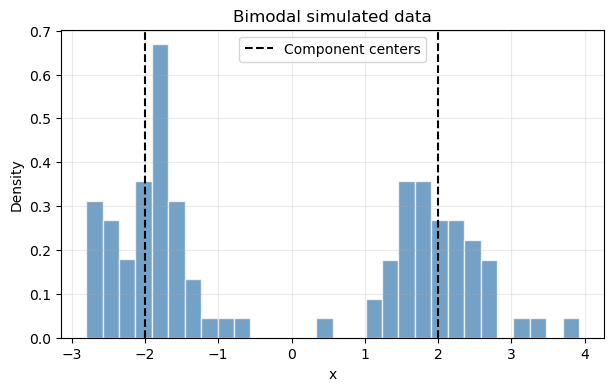

In [3]:
plt.figure(figsize=(7, 4))
plt.hist(x, bins=30, density=True, alpha=0.75, color='steelblue', edgecolor='white')
plt.axvline(-2, color='black', linestyle='--', label='Component centers')
plt.axvline(2, color='black', linestyle='--')
plt.title('Bimodal simulated data')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


### 2. Variational Inference with a Single Gaussian Family
We now perform variational inference using a simple Gaussian approximation
$$q(\mu) = \mathcal{N}(\mu_q, \sigma_q^2)$$

We use the reparameterization trick and stochastic gradient descent to find the optimal parameters.

The next two cells use PyTorch to optimize the ELBO. The random seed above makes the simulated data reproducible; the optimizer itself should converge to an approximate posterior centered near the compromise imposed by the misspecified single-Gaussian model.


In [4]:
# --- Algorithm Steps 2-4: stochastic VI with the reparameterization trick ------
import torch
#import torch.nn as nn
import torch.optim as optim

# Prepare data
x_tensor = torch.tensor(x, dtype=torch.float32)

# Variational parameters
# Step 2: the family is N(mu_q, sigma_q^2); optimizing log(sigma_q) keeps
# sigma_q positive automatically
mu_q = torch.tensor(0.0, requires_grad=True)
log_sigma_q = torch.tensor(0.0, requires_grad=True)

optimizer = optim.Adam([mu_q, log_sigma_q], lr=0.05)
num_iters = 1000
elbo_vals = []

start_time = time.time()

# Step 4: gradient ascent on the ELBO (Adam minimizes loss = -ELBO)
for _ in range(num_iters):
    # Reparameterization trick
    # Step 4: mu = mu_q + sigma_q * eps -- randomness comes from eps, so
    # gradients can flow back into mu_q and log_sigma_q
    eps = torch.randn(100)
    mu_sample = mu_q + torch.exp(log_sigma_q) * eps

    # Step 3: the three ELBO ingredients, averaged over the eps samples:
    #   log prior      (model: mu ~ N(0, 5^2), up to a constant)
    #   log likelihood (model: x_i ~ N(mu, 0.5^2), up to a constant)
    #   - log q        (the entropy term; dropping it collapses sigma_q to 0)
    log_prior = -0.5 * (mu_sample / 5)**2
    log_likelihood = -0.5 * torch.sum((x_tensor - mu_sample[:, None])**2, dim=1) / 0.5**2
    log_q = -0.5 * ((eps)**2 + 2 * log_sigma_q + np.log(2 * np.pi))

    elbo = torch.mean(log_prior + log_likelihood - log_q)
    loss = -elbo
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    elbo_vals.append(elbo.item())

elapsed_vi1 = time.time() - start_time

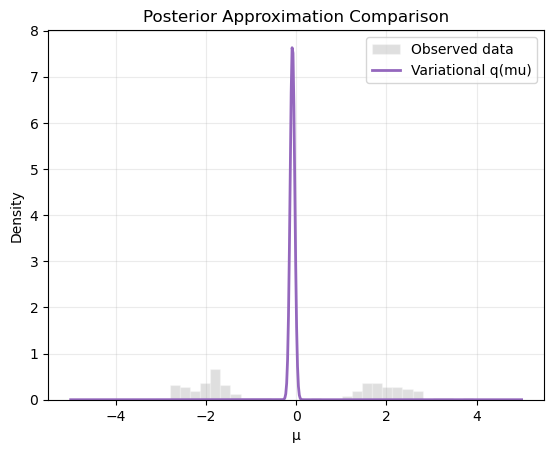

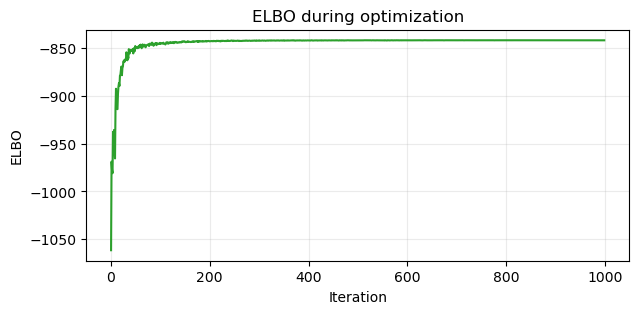

VI mean: -0.082
VI stddev: 0.052
Elapsed time for VI (1 Gaussian): 0.23 seconds


In [5]:
# --- Algorithm Step 5: report the optimized q as the approximate posterior -----

# Plot results
mu_q_val = mu_q.detach().numpy()
sigma_q_val = torch.exp(log_sigma_q).detach().numpy()
from scipy.stats import norm
xx = np.linspace(-5, 5, 500)
vi_density = norm.pdf(xx, mu_q_val, sigma_q_val)

plt.hist(x, bins=30, density=True, alpha=0.25, color='gray', edgecolor='white', label='Observed data')
plt.plot(xx, vi_density, label='Variational q(mu)', linewidth=2, color='tab:purple')
plt.title("Posterior Approximation Comparison")
plt.xlabel("μ")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(elbo_vals, color='tab:green')
plt.title('ELBO during optimization')
plt.xlabel('Iteration')
plt.ylabel('ELBO')
plt.grid(True, alpha=0.25)
plt.show()

print(f"VI mean: {mu_q_val:.3f}")
print(f"VI stddev: {sigma_q_val:.3f}")
print(f"Elapsed time for VI (1 Gaussian): {elapsed_vi1:.2f} seconds")

### 3. When it matches..

The data are bimodal, so a single Gaussian approximation is too restrictive. A quick fix is to change the variational family so it can represent two modes.

Here we use a two-component Gaussian mixture approximation
$$
q(x)=
\frac{1}{2}\,\mathcal{N}(m_1,s_1^2)+\frac{1}{2}\,\mathcal{N}(m_2,s_2^2).
$$

This is no longer a full Bayesian posterior over a parameter $\mu$; it is a variational approximation to the observed density. The point is visual: if the variational family has the right shape, optimization can recover the two modes.


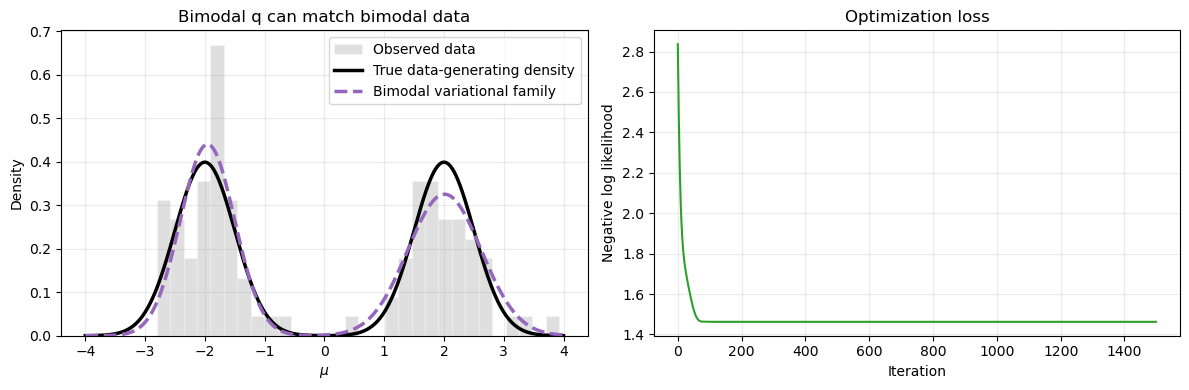

Fitted component means: -1.956, 2.008
Fitted component stddevs: 0.453, 0.613
Elapsed time for bimodal variational fit: 0.33 seconds


In [6]:
# --- Bimodal variational family: a two-Gaussian mixture -----------------------
# Same data x from the first example. Now q has two modes, so it can match the
# main feature of the data-generating process.
import torch.nn.functional as F

x_mix_tensor = torch.tensor(x, dtype=torch.float32)

m_raw = torch.tensor([-1.0, 1.0], dtype=torch.float32, requires_grad=True)
log_s_raw = torch.tensor([-0.2, -0.2], dtype=torch.float32, requires_grad=True)
optimizer_mix = optim.Adam([m_raw, log_s_raw], lr=0.03)
loss_mix_vals = []

def mixture_density_grid(grid, means, sds):
    density = np.zeros_like(grid, dtype=float)
    for mean, sd in zip(means, sds):
        density += 0.5 * norm.pdf(grid, mean, sd)
    return density

start_time = time.time()
for _ in range(1500):
    means = torch.sort(m_raw).values
    sds = F.softplus(log_s_raw) + 1e-3

    dist = torch.distributions.Normal(means[:, None], sds[:, None])
    log_component_density = dist.log_prob(x_mix_tensor[None, :]) + np.log(0.5)
    log_q_x = torch.logsumexp(log_component_density, dim=0)

    # Minimize the negative log likelihood under the variational mixture family.
    loss = -torch.mean(log_q_x)
    optimizer_mix.zero_grad()
    loss.backward()
    optimizer_mix.step()
    loss_mix_vals.append(loss.item())

elapsed_vi_mix = time.time() - start_time

means_mix = torch.sort(m_raw).values.detach().numpy()
sds_mix = (F.softplus(log_s_raw) + 1e-3).detach().numpy()
sds_mix = sds_mix[np.argsort(m_raw.detach().numpy())]

xx = np.linspace(-4, 4, 600)
true_density = 0.5 * norm.pdf(xx, -2, 0.5) + 0.5 * norm.pdf(xx, 2, 0.5)
fit_density = mixture_density_grid(xx, means_mix, sds_mix)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(x, bins=30, density=True, alpha=0.25, color='gray', edgecolor='white', label='Observed data')
axs[0].plot(xx, true_density, linewidth=2.5, color='black', label='True data-generating density')
axs[0].plot(xx, fit_density, linewidth=2.5, color='tab:purple', linestyle='--', label='Bimodal variational family')
axs[0].set_title('Bimodal q can match bimodal data')
axs[0].set_xlabel(r'$\mu$')
axs[0].set_ylabel('Density')
axs[0].legend()
axs[0].grid(True, alpha=0.25)

axs[1].plot(loss_mix_vals, color='tab:green')
axs[1].set_title('Optimization loss')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Negative log likelihood')
axs[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Fitted component means: {means_mix[0]:.3f}, {means_mix[1]:.3f}")
print(f"Fitted component stddevs: {sds_mix[0]:.3f}, {sds_mix[1]:.3f}")
print(f"Elapsed time for bimodal variational fit: {elapsed_vi_mix:.2f} seconds")
